In [72]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.models import Model
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install -q datasets

from datasets import load_dataset
import pandas as pd

dataset = load_dataset("go_emotions", "simplified")

train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

(43410, 3) (5426, 3) (5427, 3)


,text,labels,id
0,My favourite food is anything I didn't have to...,[27],eebbqej
1,"Now if he does off himself, everyone will thin...",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj
3,To make her feel threatened,[14],ed7ypvh
4,Dirty Southern Wankers,[3],ed0bdzj


In [12]:
label_names = dataset["train"].features["labels"].feature.names
print(f"Number of raw GoEmotions labels: {len(label_names)}")
print(label_names)

train_df["labels"].apply(len).value_counts()

Number of raw GoEmotions labels: 28
['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


labels
1    36308
2     6541
3      532
4       28
5        1
Name: count, dtype: int64

In [13]:
from collections import Counter

all_labels = [l for labels in train_df["labels"] for l in labels]
counts = Counter(all_labels)
dist = pd.Series({label_names[k]: v for k, v in counts.items()}).sort_values(ascending=False)
print(dist)

neutral           14219
admiration         4130
approval           2939
gratitude          2662
annoyance          2470
amusement          2328
curiosity          2191
love               2086
disapproval        2022
optimism           1581
anger              1567
joy                1452
confusion          1368
sadness            1326
disappointment     1269
realization        1110
caring             1087
surprise           1060
excitement          853
disgust             793
desire              641
fear                596
remorse             545
embarrassment       303
nervousness         164
relief              153
pride               111
grief                77
dtype: int64


In [14]:
emotion_map = {
    "anger": ["anger", "annoyance", "disapproval"],
    "disgust": ["disgust"],
    "fear": ["fear", "nervousness"],
    "joy": ["joy", "amusement", "approval", "excitement", "gratitude",
            "love", "optimism", "relief", "pride", "admiration", "desire", "caring"],
    "sadness": ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
    "surprise": ["surprise", "realization", "confusion", "curiosity"],
}

In [20]:
target_classes = list(emotion_map.keys())

In [21]:
raw_to_target = {}
for target, raw_list in emotion_map.items():
    for raw in raw_list:
        raw_to_target[raw] = target

print(raw_to_target)

{'anger': 'anger', 'annoyance': 'anger', 'disapproval': 'anger', 'disgust': 'disgust', 'fear': 'fear', 'nervousness': 'fear', 'joy': 'joy', 'amusement': 'joy', 'approval': 'joy', 'excitement': 'joy', 'gratitude': 'joy', 'love': 'joy', 'optimism': 'joy', 'relief': 'joy', 'pride': 'joy', 'admiration': 'joy', 'desire': 'joy', 'caring': 'joy', 'sadness': 'sadness', 'disappointment': 'sadness', 'embarrassment': 'sadness', 'grief': 'sadness', 'remorse': 'sadness', 'surprise': 'surprise', 'realization': 'surprise', 'confusion': 'surprise', 'curiosity': 'surprise'}


In [22]:
def map_labels(labels):
    if len(labels) != 1:
        return None  # drop multi-label examples for simplicity
    raw_name = label_names[labels[0]]
    return raw_to_target.get(raw_name, None)

In [23]:
def prepare_df(df):
    df = df.copy()
    df["emotion"] = df["labels"].apply(map_labels)
    df = df.dropna(subset=["emotion"]).reset_index(drop=True)
    return df

In [24]:
train_clean = prepare_df(train_df)
val_clean = prepare_df(val_df)
test_clean = prepare_df(test_df)

print(train_clean.shape, val_clean.shape, test_clean.shape)
train_clean["emotion"].value_counts()

(23485, 4) (2956, 4) (2984, 4)


emotion
joy         12920
anger        3878
surprise     3553
sadness      2121
fear          515
disgust       498
Name: count, dtype: int64

In [25]:
label2id = {label: i for i, label in enumerate(target_classes)}
id2label = {i: label for label, i in label2id.items()}

for df in [train_clean, val_clean, test_clean]:
    df["label_id"] = df["emotion"].map(label2id)

print(label2id)
train_clean[["text", "emotion", "label_id"]].head()

{'anger': 0, 'disgust': 1, 'fear': 2, 'joy': 3, 'sadness': 4, 'surprise': 5}


,text,emotion,label_id
0,WHY THE FUCK IS BAYLESS ISOING,anger,0
1,To make her feel threatened,fear,2
2,Dirty Southern Wankers,anger,0
3,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,surprise,5
4,Yes I heard abt the f bombs! That has to be wh...,joy,3


In [26]:
for df in [train_clean, val_clean, test_clean]:
    df["label_id"] = df["emotion"].map(label2id)

print(train_clean.shape, val_clean.shape, test_clean.shape)
print(label2id)
train_clean["emotion"].value_counts()

(23485, 5) (2956, 5) (2984, 5)
{'anger': 0, 'disgust': 1, 'fear': 2, 'joy': 3, 'sadness': 4, 'surprise': 5}


emotion
joy         12920
anger        3878
surprise     3553
sadness      2121
fear          515
disgust       498
Name: count, dtype: int64

In [28]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)       # remove URLs
    text = re.sub(r"\[NAME\]|\[RELIGION\]", "", text) # GoEmotions uses these placeholders sometimes
    text = re.sub(r"[^a-z0-9\s']", " ", text)         # keep letters, numbers, apostrophes
    text = re.sub(r"\s+", " ", text).strip()
    return text

for df in [train_clean, val_clean, test_clean]:
    df["clean_text"] = df["text"].apply(clean_text)

train_clean[["text", "clean_text"]].head()

,text,clean_text
0,WHY THE FUCK IS BAYLESS ISOING,why the fuck is bayless isoing
1,To make her feel threatened,to make her feel threatened
2,Dirty Southern Wankers,dirty southern wankers
3,OmG pEyToN iSn'T gOoD eNoUgH tO hElP uS iN tHe...,omg peyton isn't good enough to help us in the...
4,Yes I heard abt the f bombs! That has to be wh...,yes i heard abt the f bombs that has to be why...


In [34]:
VOCAB_SIZE = 20000
MAX_LEN = 30  # GoEmotions texts are short (Reddit comments)

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_clean["clean_text"])

X_train = pad_sequences(tokenizer.texts_to_sequences(train_clean["clean_text"]),
                         maxlen=MAX_LEN, padding="post", truncating="post")
X_val = pad_sequences(tokenizer.texts_to_sequences(val_clean["clean_text"]),
                       maxlen=MAX_LEN, padding="post", truncating="post")
X_test = pad_sequences(tokenizer.texts_to_sequences(test_clean["clean_text"]),
                        maxlen=MAX_LEN, padding="post", truncating="post")

y_train = train_clean["label_id"].values
y_val = val_clean["label_id"].values
y_test = test_clean["label_id"].values

print(X_train.shape, X_val.shape, X_test.shape)
print(X_train[0])

(23485, 30) (2956, 30) (2984, 30)
[  84    3  155   10 6297 8963    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [35]:
reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}

def decode(seq):
    return " ".join(reverse_word_index.get(i, "?") for i in seq if i != 0)

print("Original:", train_clean["clean_text"].iloc[0])
print("Decoded: ", decode(X_train[0]))

Original: why the fuck is bayless isoing
Decoded:  why the fuck is bayless isoing


In [36]:
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip -d glove

In [37]:
import numpy as np

EMBEDDING_DIM = 100
glove_path = "glove/glove.6B.100d.txt"  

embeddings_index = {}
with open(glove_path, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print(f"Loaded {len(embeddings_index)} word vectors")

Loaded 400000 word vectors


In [38]:
word_index = tokenizer.word_index
num_words = min(VOCAB_SIZE, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, EMBEDDING_DIM))
hits, misses = 0, 0

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue
    vector = embeddings_index.get(word)
    if vector is not None:
        embedding_matrix[i] = vector
        hits += 1
    else:
        misses += 1

print(f"Hits: {hits}, Misses: {misses}")

Hits: 16384, Misses: 2342


In [40]:
embedding_layer = Embedding(
    input_dim=num_words,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False  
)

print("Embedding layer ready:", embedding_layer)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1784762948.471340      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784762948.474114      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Embedding layer ready: <Embedding name=embedding, built=True>


In [42]:
NUM_CLASSES = len(target_classes) 

lstm_model = Sequential([
    embedding_layer,
    LSTM(128),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,872,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,872,700 (7.14 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,872,700 (7.14 MB)

In [43]:
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.5589 - loss: 1.2380 - val_accuracy: 0.5907 - val_loss: 1.0639
Epoch 2/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5971 - loss: 1.0420 - val_accuracy: 0.6116 - val_loss: 0.9955
Epoch 3/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6294 - loss: 0.9682 - val_accuracy: 0.6637 - val_loss: 0.8877
Epoch 4/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6590 - loss: 0.9015 - val_accuracy: 0.6959 - val_loss: 0.8333
Epoch 5/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6890 - loss: 0.8440 - val_accuracy: 0.6932 - val_loss: 0.8161
Epoch 6/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7080 - loss: 0.7979 - val_accuracy: 0.7067 - val_loss: 0.7874
Epoch 7/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7225 - loss: 0.7631 - val_accuracy: 0.7277 - val_loss: 0.7634
Epoch 8/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7370 - loss: 0.7349 - val_accuracy: 0.

In [44]:
test_loss, test_acc = lstm_model.evaluate(X_test, y_test)
print(f"LSTM Test Accuracy: {test_acc:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7155 - loss: 0.7929
LSTM Test Accuracy: 0.7155


In [46]:
embedding_layer_gru = Embedding(
    input_dim=num_words,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=False
)

gru_model = Sequential([
    embedding_layer_gru,
    GRU(128),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation="softmax")
])

gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,872,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,872,700 (7.14 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,872,700 (7.14 MB)

In [47]:
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5640 - loss: 1.1958 - val_accuracy: 0.5836 - val_loss: 1.0597
Epoch 2/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6123 - loss: 0.9935 - val_accuracy: 0.6499 - val_loss: 0.9199
Epoch 3/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6459 - loss: 0.9139 - val_accuracy: 0.6759 - val_loss: 0.8475
Epoch 4/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6873 - loss: 0.8393 - val_accuracy: 0.7104 - val_loss: 0.7719
Epoch 5/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7174 - loss: 0.7774 - val_accuracy: 0.7388 - val_loss: 0.7379
Epoch 6/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7286 - loss: 0.7401 - val_accuracy: 0.7348 - val_loss: 0.7346
Epoch 7/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7474 - loss: 0.7030 - val_accuracy: 0.7514 - val_loss: 0.7192
Epoch 8/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7604 - loss: 0.6685 - val_accuracy: 0.

In [48]:
gru_test_loss, gru_test_acc = gru_model.evaluate(X_test, y_test)
print(f"GRU Test Accuracy: {gru_test_acc:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7165 - loss: 0.8136
GRU Test Accuracy: 0.7165


In [52]:
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                  initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                                  initializer="zeros", trainable=True)
        super().build(input_shape)

    def call(self, hidden_states):
        score = tf.tanh(tf.tensordot(hidden_states, self.W, axes=1) + self.b)  
        attention_weights = tf.nn.softmax(score, axis=1) 
        context_vector = attention_weights * hidden_states 
        context_vector = tf.reduce_sum(context_vector, axis=1)  
        return context_vector, attention_weights

In [54]:
embedding_layer_bilstm = Embedding(
    input_dim=num_words,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=False
)

inputs = Input(shape=(MAX_LEN,))
x = embedding_layer_bilstm(inputs)
lstm_out = Bidirectional(LSTM(64, return_sequences=True))(x)  # (batch, MAX_LEN, 128)
context_vector, attention_weights = AttentionLayer()(lstm_out)
x = Dropout(0.3)(context_vector)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

bilstm_attn_model = Model(inputs=inputs, outputs=outputs)
bilstm_attn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

bilstm_attn_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 30, 100)        │     1,872,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        84,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_layer                 │ [(None, 128), (None,   │           158 │
│ (AttentionLayer)                │ 30, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,965,984 (7.50 MB)

 Trainable params: 93,284 (364.39 KB)

 Non-trainable params: 1,872,700 (7.14 MB)

In [55]:
bilstm_history = bilstm_attn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Epoch 1/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.5675 - loss: 1.1824 - val_accuracy: 0.6292 - val_loss: 0.9768
Epoch 2/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6396 - loss: 0.9640 - val_accuracy: 0.6671 - val_loss: 0.8775
Epoch 3/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6717 - loss: 0.8857 - val_accuracy: 0.6844 - val_loss: 0.8384
Epoch 4/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6918 - loss: 0.8307 - val_accuracy: 0.6972 - val_loss: 0.8192
Epoch 5/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7093 - loss: 0.7910 - val_accuracy: 0.7233 - val_loss: 0.7607
Epoch 6/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7247 - loss: 0.7525 - val_accuracy: 0.7287 - val_loss: 0.7557
Epoch 7/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7331 - loss: 0.7291 - val_accuracy: 0.7331 - val_loss: 0.7406
Epoch 8/10
367/367 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7415 - loss: 0.7028 - val_accuracy: 0

In [56]:
bilstm_test_loss, bilstm_test_acc = bilstm_attn_model.evaluate(X_test, y_test)
print(f"BiLSTM+Attention Test Accuracy: {bilstm_test_acc:.4f}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7098 - loss: 0.7998
BiLSTM+Attention Test Accuracy: 0.7098


In [57]:
attn_extractor_model = Model(inputs=inputs, outputs=[outputs, attention_weights])
print("Attention extractor ready — will be used in the heatmap visualization step.")

Attention extractor ready — will be used in the heatmap visualization step.


In [58]:
!pip install -q transformers datasets evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00


In [61]:
train_ds = Dataset.from_pandas(train_clean[["clean_text", "label_id"]].rename(columns={"clean_text": "text", "label_id": "label"}))
val_ds = Dataset.from_pandas(val_clean[["clean_text", "label_id"]].rename(columns={"clean_text": "text", "label_id": "label"}))
test_ds = Dataset.from_pandas(test_clean[["clean_text", "label_id"]].rename(columns={"clean_text": "text", "label_id": "label"}))

MODEL_NAME = "distilbert-base-uncased"
hf_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [62]:
def tokenize_fn(batch):
    return hf_tokenizer(batch["text"], truncation=True, padding="max_length", max_length=MAX_LEN)

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds = val_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

train_ds = train_ds.rename_column("label", "labels")
val_ds = val_ds.rename_column("label", "labels")
test_ds = test_ds.rename_column("label", "labels")

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

Map:   0%|          | 0/23485 [00:00<?, ? examples/s]

Map:   0%|          | 0/2956 [00:00<?, ? examples/s]

Map:   0%|          | 0/2984 [00:00<?, ? examples/s]

In [63]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES, id2label=id2label, label2id=label2id
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [64]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    macro_f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "macro_f1": macro_f1}

In [65]:
training_args = TrainingArguments(
    output_dir="./distilbert_emotion",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.306407,1.195487,0.796685,0.671314
2,1.071201,1.149645,0.800744,0.689092
3,0.923364,1.164796,0.801759,0.701340


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=1101, training_loss=1.232247366459125, metrics={'train_runtime': 174.2716, 'train_samples_per_second': 404.283, 'train_steps_per_second': 6.318, 'total_flos': 546893925870600.0, 'train_loss': 1.232247366459125, 'epoch': 3.0})

In [66]:
test_results = trainer.evaluate(test_ds)
print(test_results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.233755350112915, 'eval_accuracy': 0.7855227882037533, 'eval_macro_f1': 0.6873861418200985, 'eval_runtime': 1.9091, 'eval_samples_per_second': 1563.002, 'eval_steps_per_second': 12.571, 'epoch': 3.0}


In [69]:
lstm_preds = np.argmax(lstm_model.predict(X_test), axis=1)
gru_preds = np.argmax(gru_model.predict(X_test), axis=1)
bilstm_preds = np.argmax(bilstm_attn_model.predict(X_test), axis=1)

distilbert_output = trainer.predict(test_ds)
distilbert_preds = np.argmax(distilbert_output.predictions, axis=1)

y_true = y_test  

model_preds = {
    "LSTM": lstm_preds,
    "GRU": gru_preds,
    "BiLSTM+Attention": bilstm_preds,
    "DistilBERT": distilbert_preds,
}

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [70]:
for name, preds in model_preds.items():
    print(classification_report(y_true, preds, target_names=target_classes, digits=3))

              precision    recall  f1-score   support

       anger      0.611     0.517     0.560       520
     disgust      0.549     0.368     0.441        76
        fear      0.741     0.519     0.611        77
         joy      0.766     0.906     0.830      1603
     sadness      0.672     0.521     0.587       259
    surprise      0.615     0.470     0.533       449

    accuracy                          0.715      2984
   macro avg      0.659     0.550     0.594      2984
weighted avg      0.702     0.715     0.702      2984

              precision    recall  f1-score   support

       anger      0.648     0.433     0.519       520
     disgust      0.491     0.342     0.403        76
        fear      0.671     0.714     0.692        77
         joy      0.801     0.876     0.837      1603
     sadness      0.547     0.587     0.566       259
    surprise      0.586     0.612     0.599       449

    accuracy                          0.716      2984
   macro avg      0.624

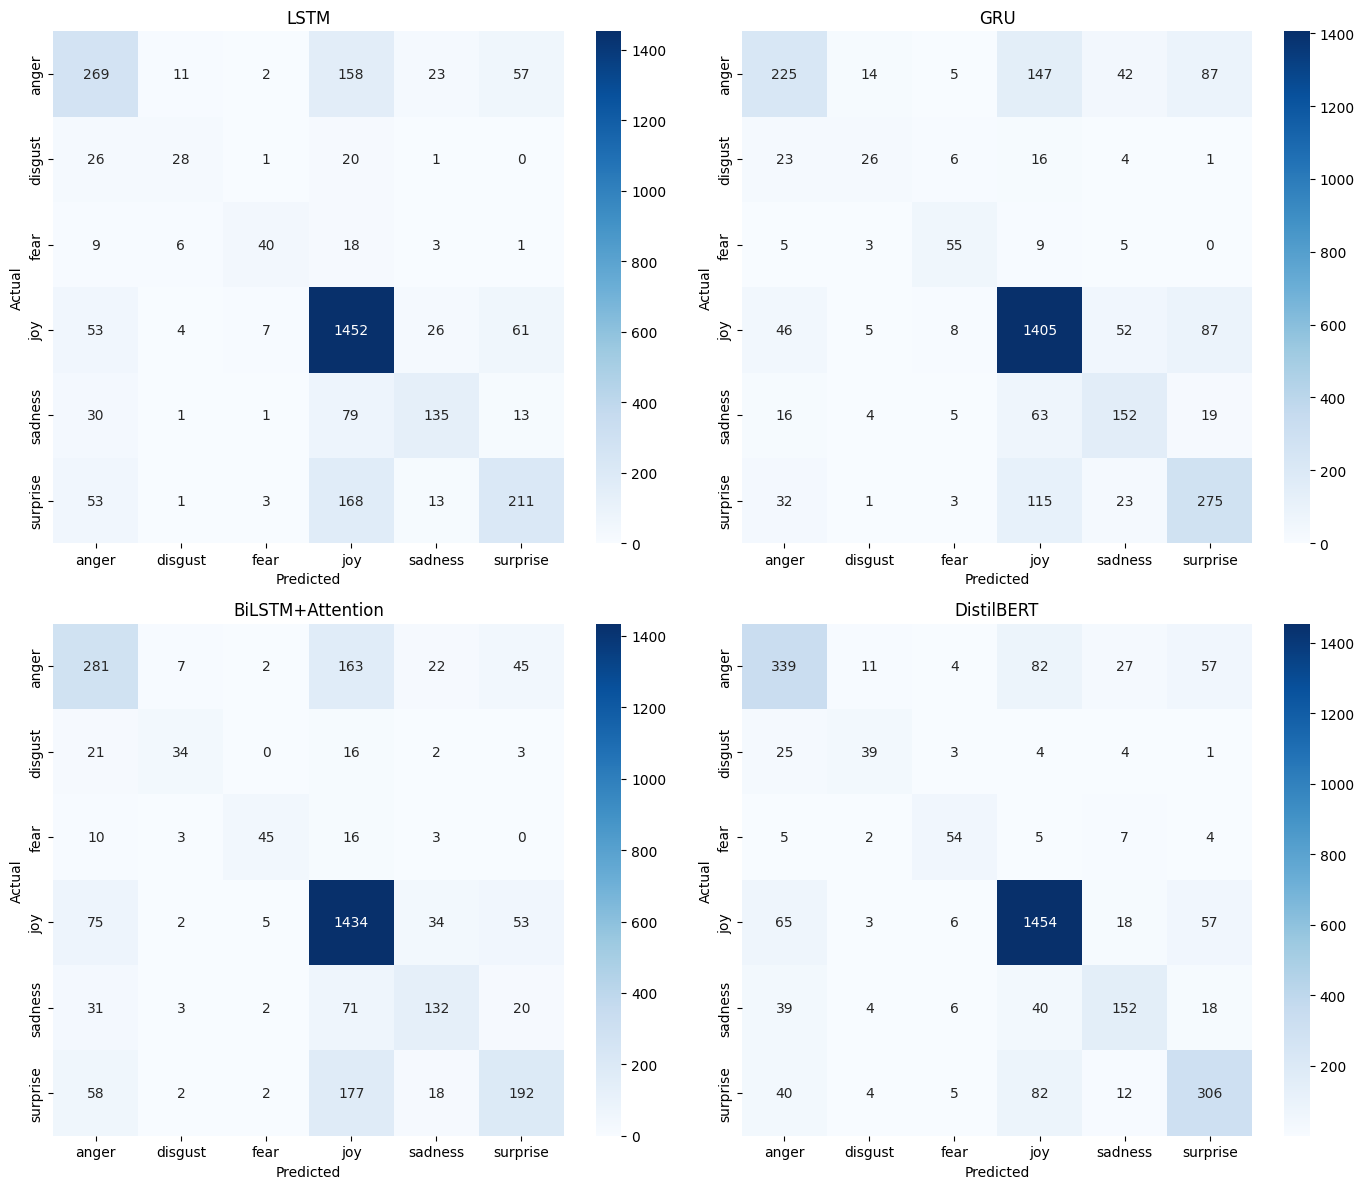

In [73]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=target_classes, yticklabels=target_classes, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [74]:
from sklearn.metrics import accuracy_score, f1_score

summary = []
for name, preds in model_preds.items():
    acc = accuracy_score(y_true, preds)
    macro_f1 = f1_score(y_true, preds, average="macro")
    summary.append({"Model": name, "Accuracy": acc, "Macro F1": macro_f1})

summary_df = pd.DataFrame(summary).sort_values("Macro F1", ascending=False)
print(summary_df)

              Model  Accuracy  Macro F1
3        DistilBERT  0.785523  0.687386
2  BiLSTM+Attention  0.709786  0.611026
1               GRU  0.716488  0.602667
0              LSTM  0.715483  0.593670


In [75]:
sample_texts = test_clean["clean_text"].iloc[:5].tolist()
sample_labels = test_clean["emotion"].iloc[:5].tolist()

sample_seqs = pad_sequences(
    tokenizer.texts_to_sequences(sample_texts),
    maxlen=MAX_LEN, padding="post", truncating="post"
)

preds, attn_weights = attn_extractor_model.predict(sample_seqs)
pred_labels = [id2label[i] for i in np.argmax(preds, axis=1)]

attn_weights = attn_weights.squeeze(-1)  
print(attn_weights.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
(5, 30)


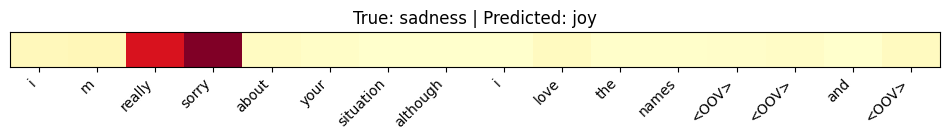

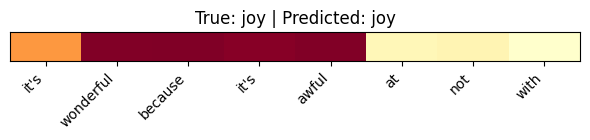

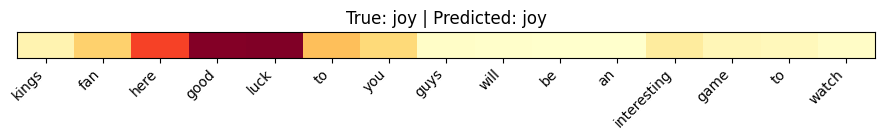

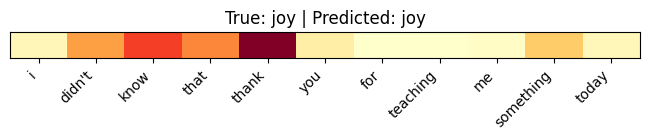

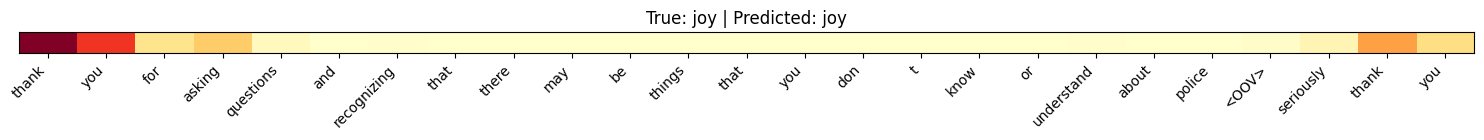

In [76]:
def plot_attention(text, weights, true_label, pred_label, max_len=MAX_LEN):
    tokens = tokenizer.texts_to_sequences([text])[0][:max_len]
    words = [reverse_word_index.get(t, "?") for t in tokens]
    w = weights[:len(words)]

    fig, ax = plt.subplots(figsize=(max(6, len(words) * 0.6), 1.5))
    ax.imshow([w], cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, rotation=45, ha="right")
    ax.set_yticks([])
    ax.set_title(f"True: {true_label} | Predicted: {pred_label}")
    plt.tight_layout()
    plt.show()

for i in range(5):
    plot_attention(sample_texts[i], attn_weights[i], sample_labels[i], pred_labels[i])

In [77]:
for i in range(5):
    tokens = tokenizer.texts_to_sequences([sample_texts[i]])[0][:MAX_LEN]
    words = [reverse_word_index.get(t, "?") for t in tokens]
    w = attn_weights[i][:len(words)]
    top_idx = np.argsort(w)[::-1][:3]
    top_words = [(words[j], round(float(w[j]), 3)) for j in top_idx]
    print(f"Text: {sample_texts[i]}")
    print(f"True: {sample_labels[i]} | Pred: {pred_labels[i]} | Top words: {top_words}\n")

Text: i m really sorry about your situation although i love the names sapphira cirilla and scarlett
True: sadness | Pred: joy | Top words: [('sorry', 0.163), ('really', 0.133), ('m', 0.031)]

Text: it's wonderful because it's awful at not with
True: joy | Pred: joy | Top words: [('because', 0.123), ('awful', 0.122), ('wonderful', 0.122)]

Text: kings fan here good luck to you guys will be an interesting game to watch
True: joy | Pred: joy | Top words: [('luck', 0.127), ('good', 0.126), ('here', 0.09)]

Text: i didn't know that thank you for teaching me something today
True: joy | Pred: joy | Top words: [('thank', 0.114), ('know', 0.083), ('that', 0.07)]

Text: thank you for asking questions and recognizing that there may be things that you don t know or understand about police tactics seriously thank you
True: joy | Pred: joy | Top words: [('thank', 0.14), ('you', 0.102), ('thank', 0.072)]



In [78]:
!pip install -q gradio

In [81]:
from transformers import pipeline

In [83]:
import os
print(os.getcwd())
print(os.listdir("."))

/kaggle/working
['.virtual_documents', 'glove', 'glove.6B.zip', 'distilbert_emotion']


In [84]:
trainer.save_model("distilbert_emotion_final")
hf_tokenizer.save_pretrained("distilbert_emotion_final")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('distilbert_emotion_final/tokenizer_config.json',
 'distilbert_emotion_final/tokenizer.json')

In [85]:
import os
model_path = os.path.abspath("distilbert_emotion_final")
print(model_path)
print(os.listdir(model_path))  

emotion_pipe = pipeline(
    "text-classification",
    model=model_path,
    tokenizer=model_path,
    top_k=None
)

/kaggle/working/distilbert_emotion_final
['tokenizer.json', 'config.json', 'tokenizer_config.json', 'training_args.bin', 'model.safetensors']


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [87]:
import gradio as gr

In [88]:
emotion_pipe = pipeline(
    "text-classification",
    model="distilbert_emotion_final",
    tokenizer="distilbert_emotion_final",
    top_k=None
)

EMOTION_COLORS = {
    "joy": "#FFC107",
    "sadness": "#2196F3",
    "anger": "#F44336",
    "fear": "#9C27B0",
    "surprise": "#FF9800",
    "disgust": "#4CAF50",
}

EMOTION_EMOJIS = {
    "joy": "😊",
    "sadness": "😢",
    "anger": "😠",
    "fear": "😨",
    "surprise": "😲",
    "disgust": "🤢",
}

def predict_emotion(text):
    if not text or not text.strip():
        return "—", None, ""

    results = emotion_pipe(text)[0]
    results = sorted(results, key=lambda x: x["score"], reverse=True)
    labels = [r["label"] for r in results]
    scores = [r["score"] for r in results]
    colors = [EMOTION_COLORS.get(l, "#999999") for l in labels]

    top_label = labels[0]
    top_score = scores[0]
    top_html = f"""
    <div style='text-align:center; padding: 18px; border-radius: 16px;
                background: linear-gradient(135deg, {colors[0]}22, {colors[0]}11);
                border: 2px solid {colors[0]};'>
        <div style='font-size: 46px;'>{EMOTION_EMOJIS.get(top_label,"")}</div>
        <div style='font-size: 26px; font-weight: 700; color: {colors[0]};
                     text-transform: capitalize; margin-top: 4px;'>{top_label}</div>
        <div style='font-size: 15px; color: #666; margin-top: 2px;'>
            {top_score*100:.1f}% confidence</div>
    </div>
    """

    fig, ax = plt.subplots(figsize=(6, 3.2))
    bars = ax.barh(labels[::-1], scores[::-1], color=colors[::-1])
    ax.set_xlim(0, 1)
    ax.set_xlabel("Confidence")
    ax.set_title("Emotion Confidence Breakdown", fontsize=13, fontweight="bold")
    for bar, score in zip(bars, scores[::-1]):
        ax.text(min(score + 0.02, 0.93), bar.get_y() + bar.get_height()/2,
                f"{score*100:.1f}%", va="center", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()

    return top_html, fig, ""

theme = gr.themes.Soft(
    primary_hue="violet",
    secondary_hue="pink",
    neutral_hue="slate",
    font=[gr.themes.GoogleFont("Poppins"), "sans-serif"],
)

custom_css = """
#title { text-align: center; font-weight: 800; font-size: 30px;
         background: linear-gradient(90deg, #7C3AED, #EC4899);
         -webkit-background-clip: text; -webkit-text-fill-color: transparent; }
#subtitle { text-align: center; color: #6B7280; margin-bottom: 10px; }
.gradio-container { max-width: 900px !important; margin: auto !important; }
"""

with gr.Blocks(theme=theme, css=custom_css, title="Emotion Classifier") as demo:
    gr.HTML("<div id='title'>💜 Emotion Classifier</div>")
    gr.HTML("<div id='subtitle'>Powered by fine-tuned DistilBERT · 6-class emotion detection</div>")

    with gr.Row():
        with gr.Column(scale=1):
            text_input = gr.Textbox(
                lines=4,
                placeholder="Type how you feel, or paste any sentence...",
                label="Your text",
            )
            submit_btn = gr.Button("Analyze Emotion", variant="primary")
            gr.Examples(
                examples=[
                    "I can't believe how amazing this is!",
                    "I'm so scared right now, I don't know what to do.",
                    "This is disgusting, I can't even look at it.",
                    "Wow, I never expected that to happen!",
                ],
                inputs=text_input,
            )
        with gr.Column(scale=1):
            top_result = gr.HTML(label="Dominant Emotion")
            chart_output = gr.Plot(label="Confidence Breakdown")

    error_box = gr.Textbox(visible=False)

    submit_btn.click(predict_emotion, inputs=text_input, outputs=[top_result, chart_output, error_box])
    text_input.submit(predict_emotion, inputs=text_input, outputs=[top_result, chart_output, error_box])

demo.launch(share=True, debug=True)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

/tmp/ipykernel_58/3585634575.py:78: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=theme, css=custom_css, title="Emotion Classifier") as demo:
/tmp/ipykernel_58/3585634575.py:78: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(theme=theme, css=custom_css, title="Emotion Classifier") as demo:


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://cd2a5783f3365a3526.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://cd2a5783f3365a3526.gradio.live


In [94]:
import shutil

shutil.make_archive("distilbert_emotion_final", "zip", "distilbert_emotion_final")
print("Zipped successfully.")

Zipped successfully.


In [95]:
from IPython.display import FileLink

FileLink("distilbert_emotion_final.zip")

/kaggle/working/distilbert_emotion_final.zip